CUDA Available: True
GPU: Tesla T4


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

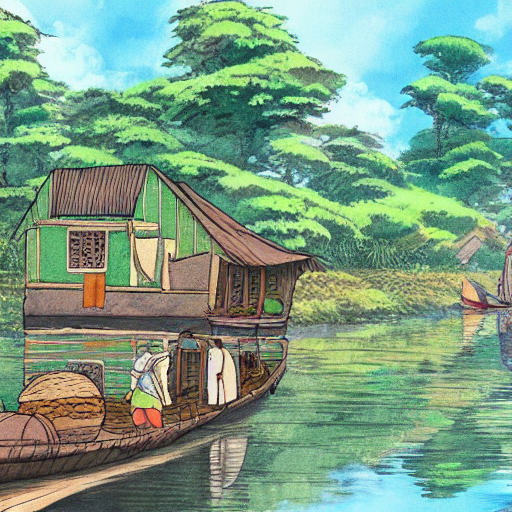

In [8]:
!pip install -q diffusers transformers accelerate torch safetensors

import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

# Check GPU
print("CUDA Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# Load model using GPU
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

# Prompt
prompt = "A Kerala backwater village in Studio Ghibli style"

# Generate image
image = pipe(
    prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

# Save image
image.save("generated_image.png")

# Display image
image